In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("WorldCupMatches.csv")

df.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930.0,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4.0,1.0,Mexico,,4444.0,3.0,0.0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201.0,1096.0,FRA,MEX
1,1930.0,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3.0,0.0,Belgium,,18346.0,2.0,0.0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201.0,1090.0,USA,BEL
2,1930.0,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2.0,1.0,Brazil,,24059.0,2.0,0.0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201.0,1093.0,YUG,BRA
3,1930.0,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3.0,1.0,Peru,,2549.0,1.0,0.0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201.0,1098.0,ROU,PER
4,1930.0,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1.0,0.0,France,,23409.0,0.0,0.0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201.0,1085.0,ARG,FRA


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 852 entries, 0 to 851
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  852 non-null    int64         
 1   Datetime              842 non-null    datetime64[ns]
 2   Stage                 852 non-null    object        
 3   Stadium               852 non-null    object        
 4   City                  852 non-null    object        
 5   Home Team Name        852 non-null    object        
 6   Home Team Goals       852 non-null    int64         
 7   Away Team Goals       852 non-null    int64         
 8   Away Team Name        852 non-null    object        
 9   Win conditions        852 non-null    object        
 10  Attendance            852 non-null    int64         
 11  Half-time Home Goals  852 non-null    int64         
 12  Half-time Away Goals  852 non-null    int64         
 13  Home Team Initials    852

In [10]:
df.describe()

,Year,Home Team Goals,Away Team Goals,Attendance,Half-time Home Goals,Half-time Away Goals,RoundID,MatchID
count,852.000000,852.000000,852.000000,850.000000,852.000000,852.000000,8.520000e+02,8.520000e+02
mean,1985.089202,1.811033,1.022300,45164.800000,0.708920,0.428404,1.066177e+07,6.134687e+07
std,22.448825,1.610255,1.087573,23485.249247,0.937414,0.691252,2.729613e+07,1.110572e+08
min,1930.000000,0.000000,0.000000,2000.000000,0.000000,0.000000,2.010000e+02,2.500000e+01
25%,1970.000000,1.000000,0.000000,30000.000000,0.000000,0.000000,2.620000e+02,1.188750e+03
50%,1990.000000,2.000000,1.000000,41579.500000,0.000000,0.000000,3.370000e+02,2.191000e+03
75%,2002.000000,3.000000,2.000000,61374.500000,1.000000,1.000000,2.497220e+05,4.395006e+07
max,2014.000000,10.000000,7.000000,173850.000000,6.000000,5.000000,9.741060e+07,3.001865e+08


In [7]:
df.columns

Index(['Year', 'Datetime', 'Stage', 'Stadium', 'City', 'Home Team Name',
       'Home Team Goals', 'Away Team Goals', 'Away Team Name',
       'Win conditions', 'Attendance', 'Half-time Home Goals',
       'Half-time Away Goals', 'Referee', 'Assistant 1', 'Assistant 2',
       'RoundID', 'MatchID', 'Home Team Initials', 'Away Team Initials'],
      dtype='object')

In [8]:
df = df.dropna(subset=['Year'])

In [11]:
df['Year'] = df['Year'].astype(int)

In [13]:
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

In [15]:
df.columns = df.columns.str.strip()

In [16]:
df[['Home Team Goals', 'Away Team Goals']].describe()

,Home Team Goals,Away Team Goals
count,852.000000,852.000000
mean,1.811033,1.022300
std,1.610255,1.087573
min,0.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,1.000000
75%,3.000000,2.000000
max,10.000000,7.000000


In [17]:
df['Home Team Goals'] = df['Home Team Goals'].astype(int)
df['Away Team Goals'] = df['Away Team Goals'].astype(int)
df['Half-time Home Goals'] = df['Half-time Home Goals'].astype(int)
df['Half-time Away Goals'] = df['Half-time Away Goals'].astype(int)

In [21]:
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].median())

In [23]:
df = df.drop(columns=['Referee', 'Assistant 1', 'Assistant 2', 'RoundID', 'MatchID'])

In [24]:
df['Attendance'] = df['Attendance'].astype(int)

In [26]:
df['Total Goals'] = df['Home Team Goals'] + df['Away Team Goals']

df['Goal Diff'] = abs(df['Home Team Goals'] - df['Away Team Goals'])

df['Result'] = df.apply(lambda x: 
    'Home Win' if x['Home Team Goals'] > x['Away Team Goals']
    else ('Away Win' if x['Home Team Goals'] < x['Away Team Goals']
          else 'Draw'), axis=1)

In [28]:
df.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Home Team Initials,Away Team Initials,Total Goals,Goal Diff,Result
0,1930,1930-07-13 15:00:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444,3,0,FRA,MEX,5,3,Home Win
1,1930,1930-07-13 15:00:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346,2,0,USA,BEL,3,3,Home Win
2,1930,1930-07-14 12:45:00,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059,2,0,YUG,BRA,3,1,Home Win
3,1930,1930-07-14 14:50:00,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549,1,0,ROU,PER,4,2,Home Win
4,1930,1930-07-15 16:00:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409,0,0,ARG,FRA,1,1,Home Win


In [30]:
df[['Total Goals', 'Goal Diff']].describe()

,Total Goals,Goal Diff
count,852.000000,852.000000
mean,2.833333,1.511737
std,1.954336,1.437652
min,0.000000,0.000000
25%,1.000000,1.000000
50%,3.000000,1.000000
75%,4.000000,2.000000
max,12.000000,9.000000


In [31]:
df['Result'].value_counts()

Result
Home Win    488
Draw        190
Away Win    174
Name: count, dtype: int64

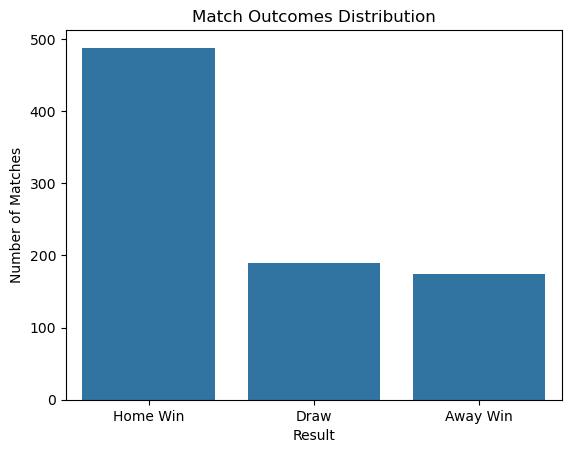

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Result', data=df)
plt.title("Match Outcomes Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.savefig("Match_outcome_dist.png")
plt.show()

# In such high pressure matches, "home teams" perfrom better, they win more matches.

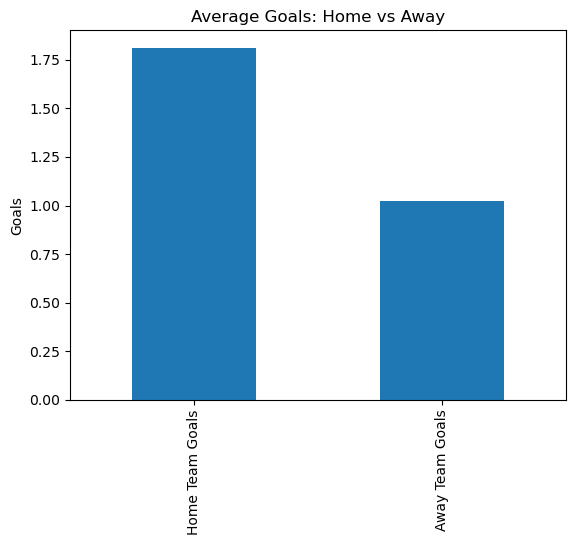

In [46]:
df[['Home Team Goals', 'Away Team Goals']].mean().plot(kind='bar')
plt.title("Average Goals: Home vs Away")
plt.ylabel("Goals")
plt.savefig("home vs away.png")
plt.show()
# Home team scores more avg goals leading them to win more matches. Home team gets more support from fans.

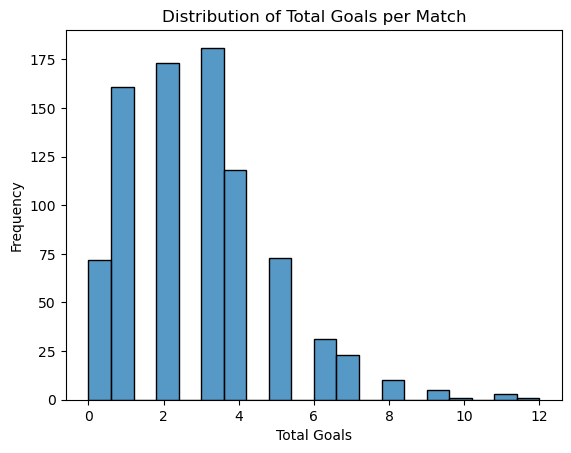

In [45]:
sns.histplot(df['Total Goals'], bins=20)
plt.title("Distribution of Total Goals per Match")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.savefig("goal_dist.png")
plt.show()
# Very high scoring matches are rare.Most matches have total goals as 2 to 4.We can safely say that matches are competitive not one sided.

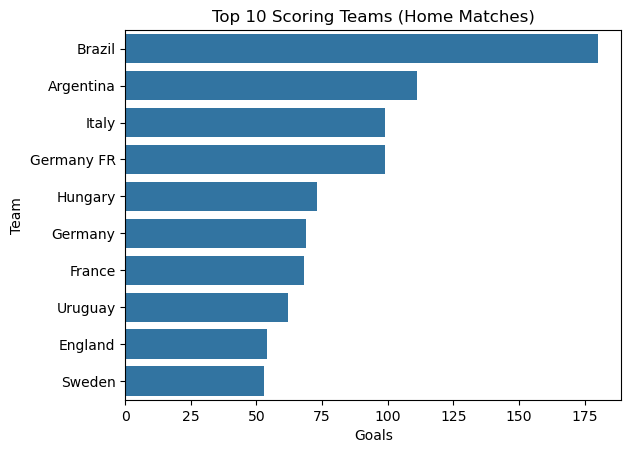

In [44]:
top_teams = df.groupby('Home Team Name')['Home Team Goals'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_teams.values, y=top_teams.index)
plt.title("Top 10 Scoring Teams (Home Matches)")
plt.xlabel("Goals")
plt.ylabel("Team")
plt.savefig("Top_teams.png")
plt.show()
# Scoring more goals wins you more matches.Brazil are five times world champions,and they have scored most goals.

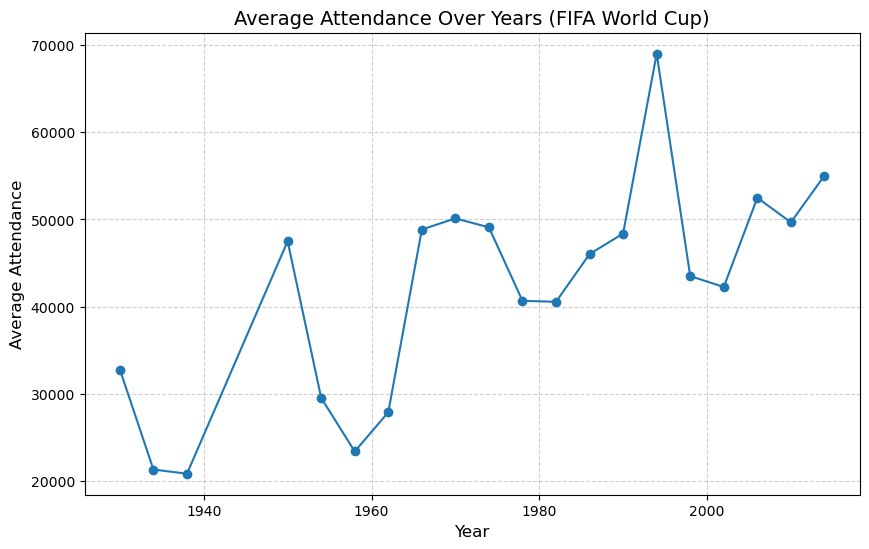

In [43]:
plt.figure(figsize=(10,6))

attendance_trend = df.groupby('Year')['Attendance'].mean()

plt.plot(attendance_trend.index, attendance_trend.values, marker='o')

plt.title("Average Attendance Over Years (FIFA World Cup)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Attendance", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("Attendance_trend.png")
plt.show()
#Average match attendance in FIFA World Cup tournaments has generally increased over time, reflecting the growing global popularity of football. A significant peak is observed around the mid-1990s, likely due to larger stadium capacities and 
#increased global viewership.

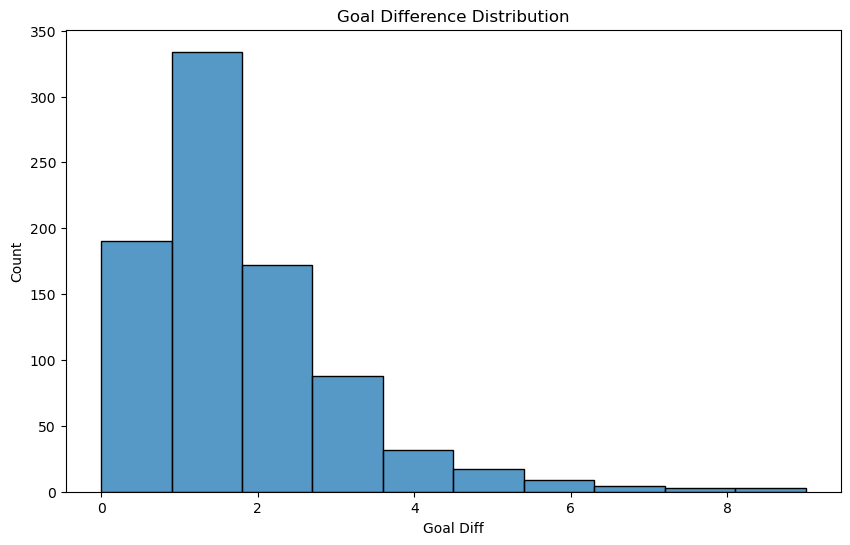

In [42]:
plt.figure(figsize=(10,6))

sns.histplot(df['Goal Diff'], bins=10)

plt.title("Goal Difference Distribution")

plt.savefig("goal_diff.png")

plt.show()
#The majority of FIFA World Cup matches are closely contested, with most games decided by a goal difference of 1–2. High-margin victories 
#are relatively rare, indicating strong competitiveness at the international level.